# 03 - RFM Segmentation
Calculate RFM (Recency, Frequency, Monetary), segment customers using rule-based/quantile score, and analyze revenue contribution by segment. Read EDA-passed data (`02_eda.ipynb`) from `data/processed/order_level.parquet`.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.features import *

In [2]:
order_level = pd.read_parquet("data/processed/order_level.parquet")

## Compute RFM
Choosing 2018-09-05 as reference date (default: max order_purchase_timestamp + 1 day).

In [3]:
rfm = compute_rfm(order_level)

Removed 467 orders which have canceled/unavailable status out of rfm computation
Computed rfm for 94983 customers (customer_unique_id), reference date: 2018-09-04 09:06:57


In [4]:
rfm.sort_values(by=["recency", "frequency", "monetary"], ascending=[True, False, False])

,customer_unique_id,recency,frequency,monetary
94648,ff22e30958c13ffe219db7d711e8f564,1,2,332.92
34432,5c58de6fb80e93396e2f35642666b693,5,1,510.96
4662,0c6d7218d5f3fa14514fd29865269993,5,1,178.25
1534,0421e7a23f21e5d54efed456aedbc513,5,1,119.42
67207,b4dcade04bc548b7e3b0243c801f8c26,5,1,106.95
...,...,...,...,...
36463,61db744d2f835035a5625b59350c6b63,700,1,53.73
50299,87776adb449c551e74c13fc34f036105,700,1,40.95
17673,2f64e403852e6893ae37485d5fcacdaf,700,1,39.09
48745,830d5b7aaa3b6f1e9ad63703bec97d23,718,1,0.00


In [5]:
rfm.describe()

,recency,frequency,monetary
count,94983.000000,94983.000000,94983.000000
mean,243.433077,1.033859,165.695145
std,152.983982,0.210811,226.747872
min,1.000000,1.000000,0.000000
25%,119.000000,1.000000,63.100000
50%,224.000000,1.000000,107.900000
75%,352.000000,1.000000,182.945000
max,729.000000,16.000000,13664.080000


## Distribution Check

In [6]:
rfm["monetary_log"] = np.log1p(rfm["monetary"])

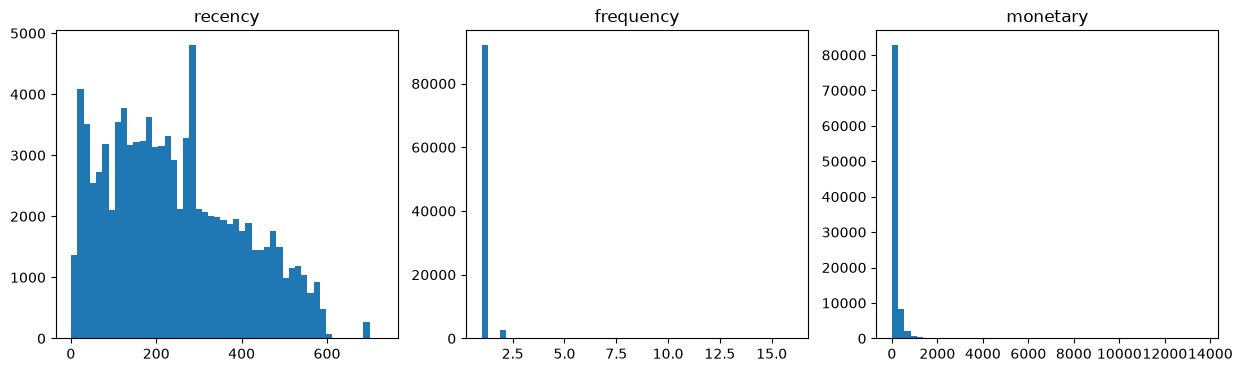

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["recency", "frequency", "monetary"]):
    ax.hist(rfm[col], bins=50)
    ax.set_title(col)
plt.show()

### Recency
There's a blank space between 600-650. This is because of the dataset
### Frequency
Nearly all the customer = 1 => cannot use this to divide customer because 90% of the customers are the same.
Retention is very low, almost the customers are one-time-buyer
### Monetary
Right-skewed. Need to be log-transformed

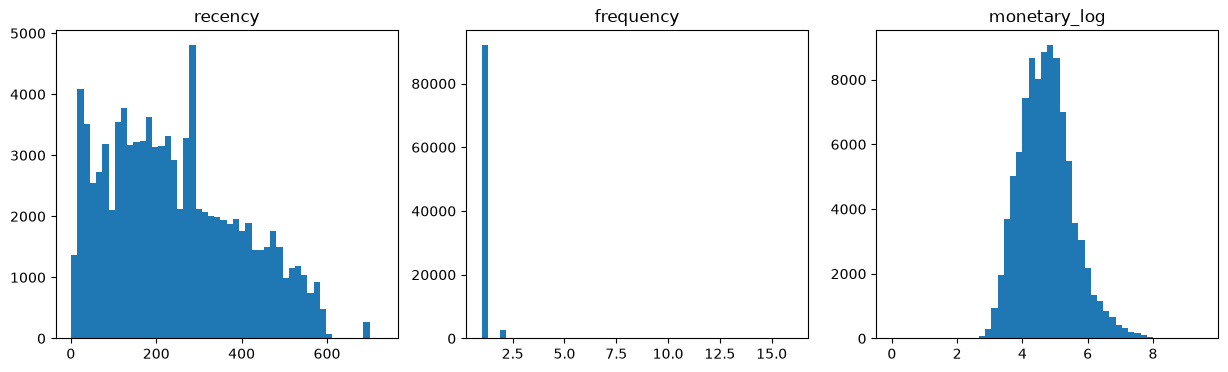

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["recency", "frequency", "monetary_log"]):
    ax.hist(rfm[col], bins=50)
    ax.set_title(col)
plt.show()

### Monetary_log
After log transformed, the distribution changed into Gaussian Distribution
### Compute frequency value percentage:

In [9]:
rfm["frequency"].value_counts(normalize=True).sort_index() * 100

frequency
1     96.960509
2      2.791026
3      0.197930
4      0.030532
5      0.009475
6      0.005264
7      0.003158
9      0.001053
16     0.001053
Name: proportion, dtype: float64

## RFM Scoring & Segmentation

In [10]:
rfm = add_rfm_scores(rfm)

rfm_segment
New Customers       36752
Hibernating         22970
Need Attention      18386
Cannot Lose Them    13988
Loyal Customers      1723
At Risk              1035
Champions             129
Name: count, dtype: int64


In [11]:
segment_summary = (
    rfm.groupby("rfm_segment")
    .agg(
        n_customers=("customer_unique_id", "count"),
        total_revenue=("monetary", "sum"),
        avg_monetary=("monetary", "mean"),
    )
    .assign(pct_customers=lambda x: x["n_customers"] / x["n_customers"].sum() * 100)
    .assign(pct_revenue=lambda x: x["total_revenue"] / x["total_revenue"].sum() * 100)
    .sort_values("total_revenue", ascending=False)
)
print(segment_summary)

                  n_customers  total_revenue  avg_monetary  pct_customers  \
rfm_segment                                                                 
New Customers           36752     6054809.99    164.747769      38.693240   
Cannot Lose Them        13988     4324287.50    309.142658      14.726846   
Need Attention          18386     2796760.59    152.113597      19.357148   
Hibernating             22970     1671978.91     72.789678      24.183275   
Loyal Customers          1723      514397.74    298.547731       1.814009   
At Risk                  1035      305858.35    295.515314       1.089669   
Champions                 129       70128.87    543.634651       0.135814   

                  pct_revenue  
rfm_segment                    
New Customers       38.472008  
Cannot Lose Them    27.476341  
Need Attention      17.770499  
Hibernating         10.623684  
Loyal Customers      3.268462  
At Risk              1.943411  
Champions            0.445596  


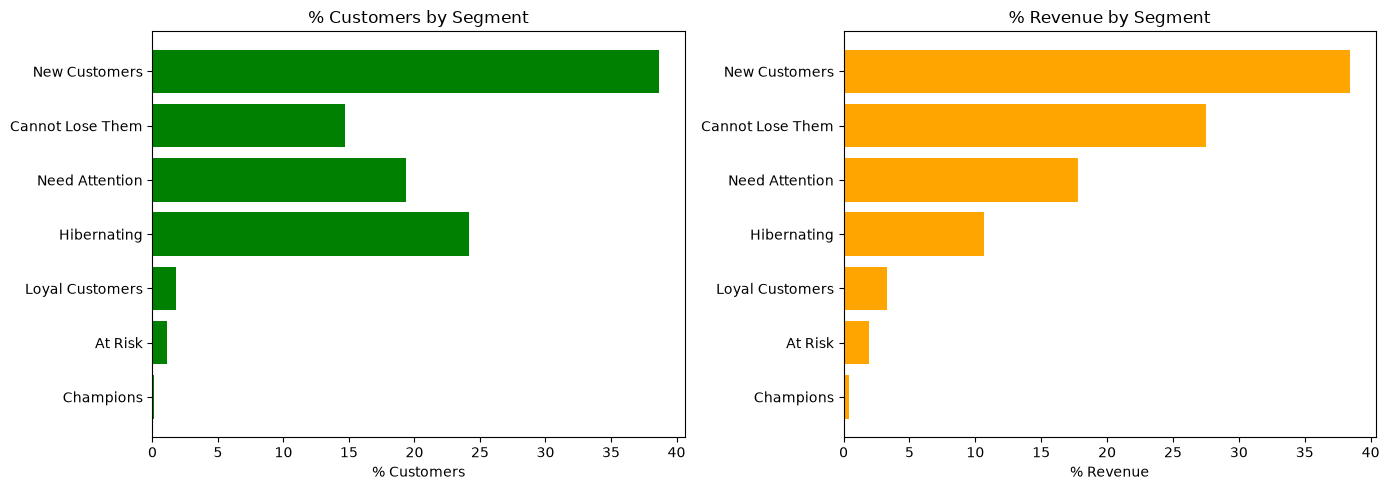

In [12]:
segment_summary = segment_summary.sort_values("total_revenue", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(segment_summary.index, segment_summary["pct_customers"], color="green")
axes[0].set_title("% Customers by Segment")
axes[0].invert_yaxis()
axes[0].set_xlabel("% Customers")

axes[1].barh(segment_summary.index, segment_summary["pct_revenue"], color="orange")
axes[1].set_title("% Revenue by Segment")
axes[1].invert_yaxis()
axes[1].set_xlabel("% Revenue")

plt.tight_layout()
plt.show()

## Insights

**1. "Cannot Lose Them" is the most important finding of this analysis**
This group only accounts for **14.7% of customers but contributes 27.5% of revenue** - a contribution rate nearly double the quantity proportion. These are customers who used to spend very high amounts (average 309 BRL/customer, second highest after Champions) but have not returned for a long time (low recency). This group is the highest priority for a win-back campaign — the cost of retaining this group is much lower than attracting new customers of equal value.

**2. "New Customers" contribute the largest revenue in total, but the average value is low**
Accounts for 38.7% of customers and 38.5% of revenue (proportionate ratio) — but `avg_monetary` is only 164.7 BRL, much lower than Cannot Lose Them or Champions. This is a new group, the value of each customer is not high - an opportunity to implement a second purchase incentive program (if part of this group can be converted to "Loyal", the average value can increase significantly).

**3. Champions are extremely small but have an exceptionally high average value**
Only 129 customers (0.14%) but `avg_monetary` = 543.6 BRL — ~3.3 times more than New Customers. Although the total revenue contribution is only 0.45% (due to the small number), this is a group that should have its own VIP care program to maximize lifetime value and encourage referrals.

**4. Hibernating accounts for the majority (24.2%) but contributes the lowest revenue by proportion (10.6%).**
`avg_monetary` is only 72.8 BRL — the lowest of the bunch. This is a one-time customer, low order value, has been inactive for a long time — re-engagement priority should be lower than Cannot Lose Them, because the expected ROI is lower.

### Proposed comprehensive actions (in order of priority)
1. **Cannot Lose Them**: Personalized emails/vouchers target high order value — #1 priority because of highest revenue/customer ratio in large groups.
2. **New Customers**: Second order incentive program (discount on next purchase) — convert to Loyal/Champions.
3. **Champions**: Private VIP/loyalty program, referral incentive.
4. **Hibernating**: Low cost re-engagement (automatic emails), does not invest a lot of resources.

## Save RFM output

In [13]:
rfm.to_parquet("data/processed/rfm.parquet", index=False)